---
# Archi — Data Pipeline + Logistic Regression + Naive Bayes
---

Train shape: (20631, 26)
Test shape : (13096, 26)


,unit,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044



Kept 16 features: ['op1', 'op2', 'sensor2', 'sensor3', 'sensor4', 'sensor7', 'sensor8', 'sensor9', 'sensor11', 'sensor12', 'sensor13', 'sensor14', 'sensor15', 'sensor17', 'sensor20', 'sensor21']


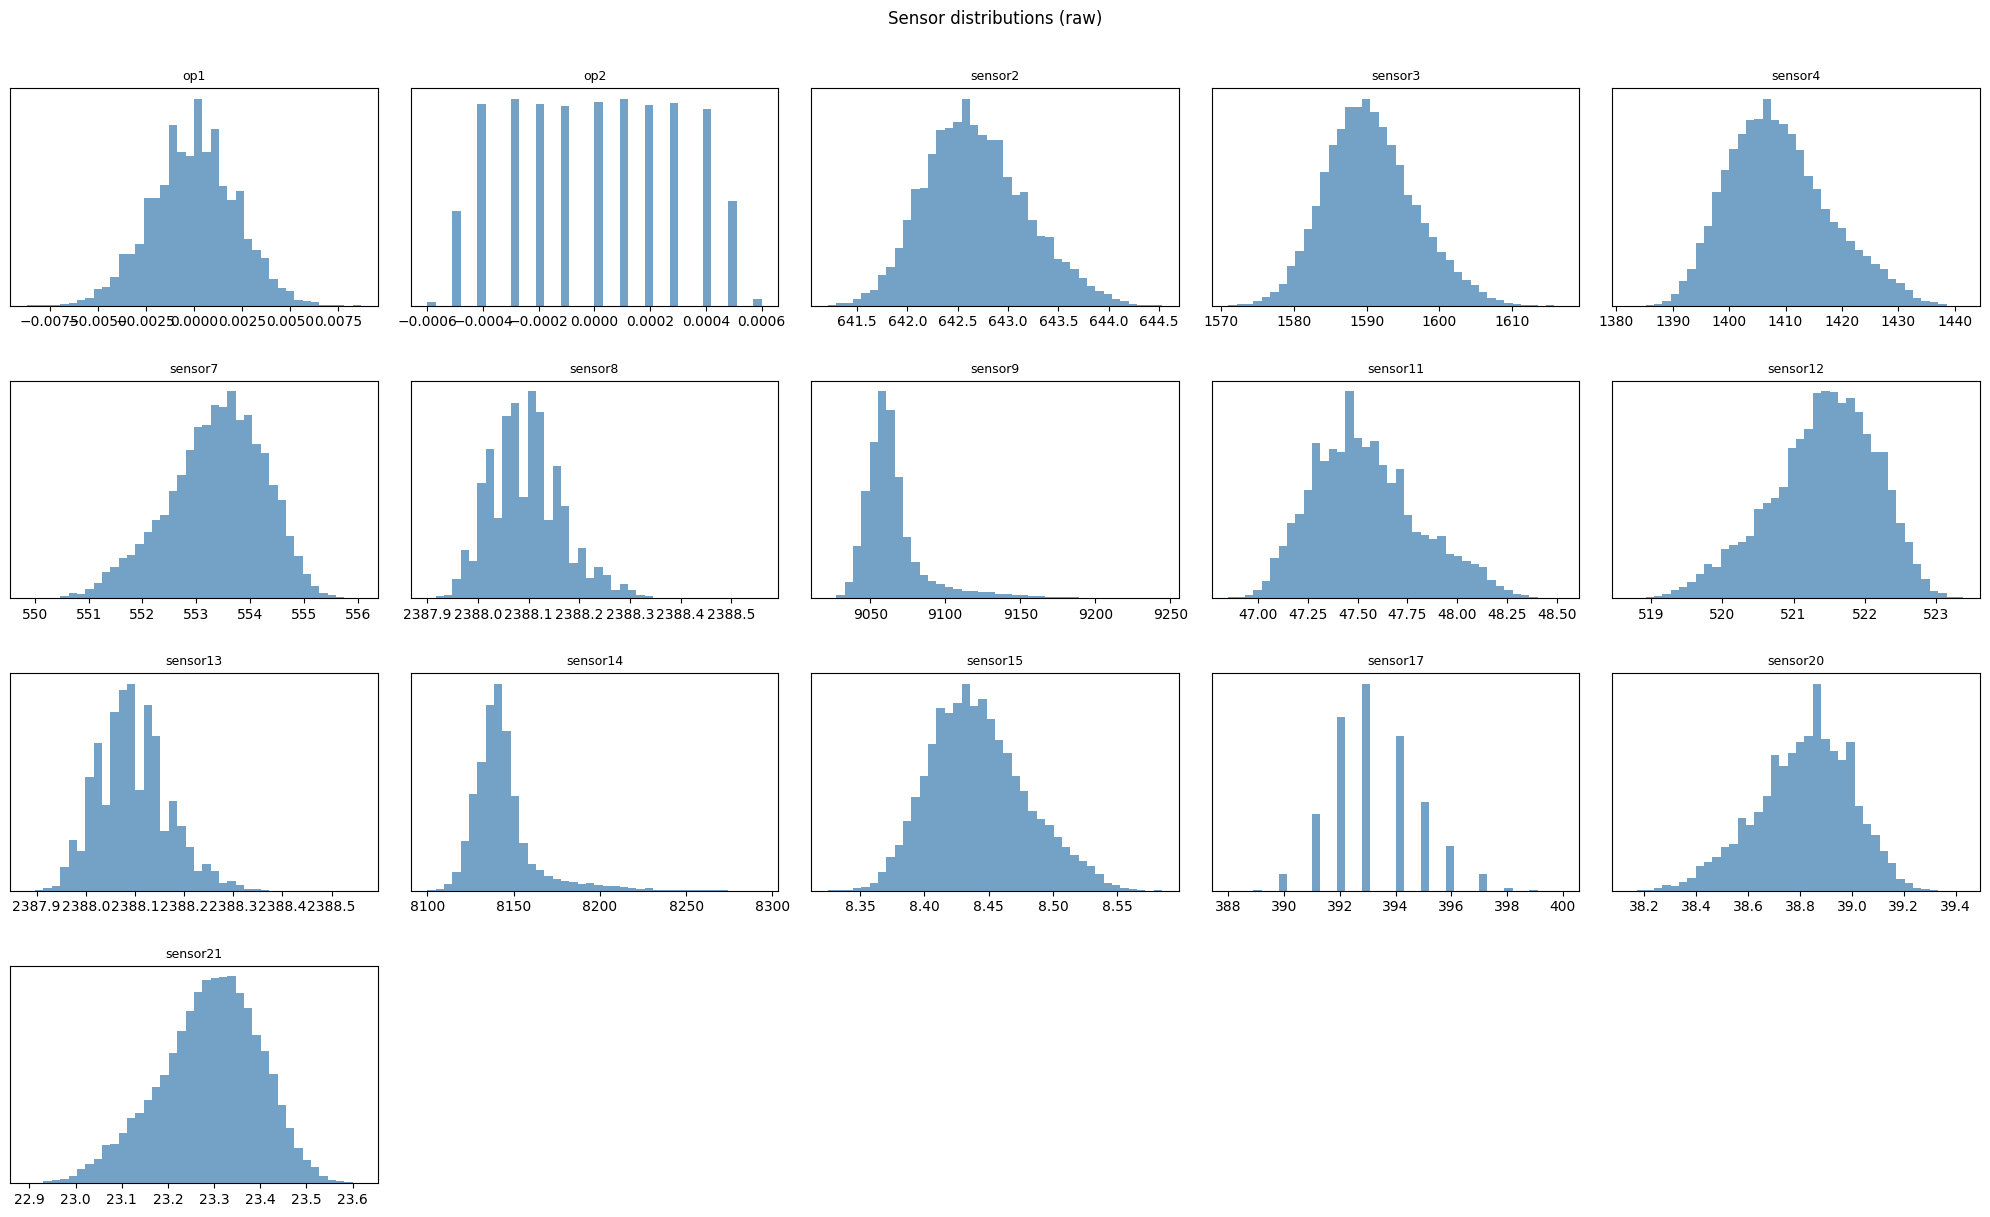

Normalization done ✓

Label distribution:
label
0    17531
1     3100
Positive rate (near-failure): 15.03%

Exported train_clean.csv and test_clean.csv ✓

X_train: (16504, 16)  |  X_val: (4127, 16)
Train positive rate: 15.03%
Fitting 5 folds for each of 6 candidates, totalling 30 fits

Best C  : 100
Best CV F1 : 0.846
Fitting 5 folds for each of 10 candidates, totalling 50 fits

Best var_smoothing : 1.00e-11
Best CV F1         : 0.838

  Logistic Regression
  F1 per fold  : [0.852 0.851 0.842 0.853 0.832]
  F1 mean±std  : 0.846 ± 0.008
  95% CI       : [0.839,  0.853]
  AUC          : 0.992
  Precision    : 0.757
  Recall       : 0.960

  Gaussian Naive Bayes
  F1 per fold  : [0.839 0.84  0.84  0.841 0.828]
  F1 mean±std  : 0.838 ± 0.005
  95% CI       : [0.833,  0.842]
  AUC          : 0.992
  Precision    : 0.742
  Recall       : 0.961

VIF scores:
 feature       VIF
sensor12 27.485961
 sensor7 25.425328
sensor20 21.045484
sensor21 20.867707
sensor11 15.257782
 sensor4 14.439165
sens

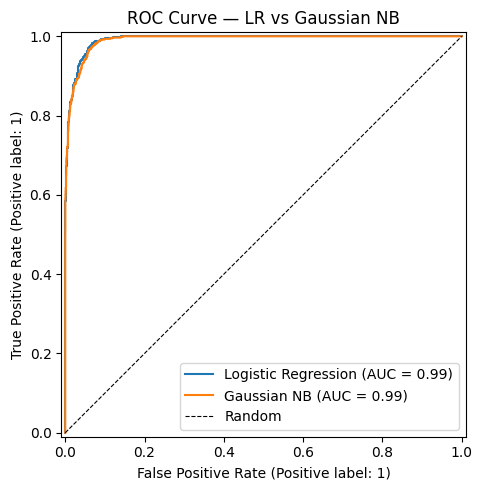

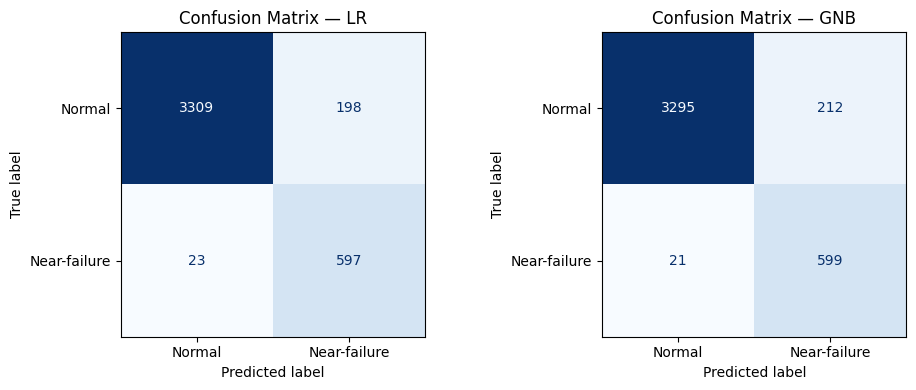

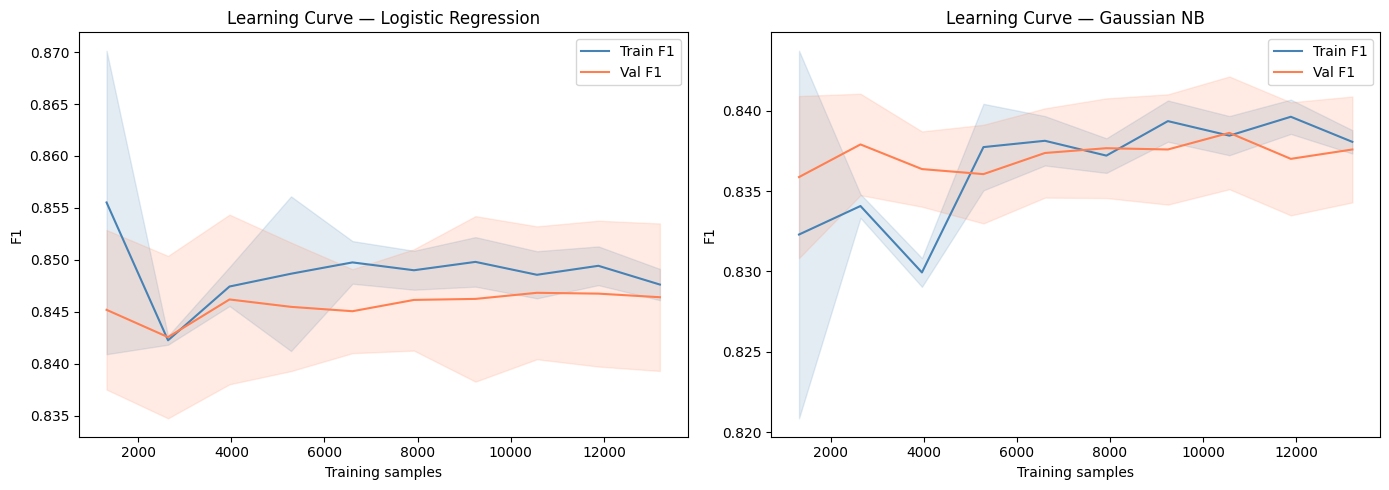


All models saved to models/ ✓

✅ Pipeline complete!


In [12]:
# ============================================================
# PREDICTIVE MAINTENANCE
# ============================================================

# 1. IMPORTS
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, os
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     GridSearchCV, cross_validate,
                                     learning_curve)
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import RocCurveDisplay, ConfusionMatrixDisplay
from statsmodels.stats.outliers_influence import variance_inflation_factor

os.makedirs('models',  exist_ok=True)
os.makedirs('outputs', exist_ok=True)

# ============================================================
# 2. LOAD DATA
# ============================================================
col_names = (
    ['unit', 'cycle'] +
    ['op1', 'op2', 'op3'] +
    [f'sensor{i}' for i in range(1, 22)]
)

train_df = pd.read_csv('train_FD001.txt', sep=r'\s+', header=None, names=col_names)
test_df  = pd.read_csv('test_FD001.txt',  sep=r'\s+', header=None, names=col_names)

print(f"Train shape: {train_df.shape}")
print(f"Test shape : {test_df.shape}")
display(train_df.head())

# ============================================================
# 3. DROP USELESS SENSORS
# ============================================================
drop_cols = ['sensor1','sensor5','sensor6','sensor10',
             'sensor16','sensor18','sensor19','op3']

train_df.drop(columns=drop_cols, inplace=True)
test_df.drop(columns=drop_cols, inplace=True)

feature_cols = [c for c in train_df.columns
                if c.startswith('sensor') or c.startswith('op')]

print(f"\nKept {len(feature_cols)} features: {feature_cols}")

# ============================================================
# 4. EDA — SENSOR DISTRIBUTIONS
# ============================================================
fig, axes = plt.subplots(4, 5, figsize=(20, 12))
for ax, col in zip(axes.flatten(), feature_cols):
    ax.hist(train_df[col], bins=40, color='steelblue', alpha=0.75, edgecolor='none')
    ax.set_title(col, fontsize=9)
    ax.set_yticks([])
for ax in axes.flatten()[len(feature_cols):]:
    ax.set_visible(False)
plt.suptitle("Sensor distributions (raw)", y=1.01, fontsize=12)
plt.tight_layout()
plt.savefig('outputs/eda_distributions.png', dpi=130, bbox_inches='tight')
plt.show()

# ============================================================
# 5. NORMALIZE PER ENGINE UNIT (MinMaxScaler)
# ============================================================
def normalize_per_unit(df, feature_cols):
    df = df.copy()
    scalers = {}
    for unit_id, group in df.groupby('unit'):
        scaler = MinMaxScaler()
        df.loc[group.index, feature_cols] = scaler.fit_transform(group[feature_cols])
        scalers[unit_id] = scaler
    return df, scalers

train_df, train_scalers = normalize_per_unit(train_df, feature_cols)

# Test set — use a single global scaler fitted on train
global_scaler = MinMaxScaler()
global_scaler.fit(train_df[feature_cols])
test_df[feature_cols] = global_scaler.transform(test_df[feature_cols])

print("Normalization done ✓")

# ============================================================
# 6. COMPUTE RUL + BINARY LABEL
# ============================================================
THRESHOLD = 30

max_cycles       = train_df.groupby('unit')['cycle'].max().rename('max_cycle')
train_df         = train_df.join(max_cycles, on='unit')
train_df['RUL']  = train_df['max_cycle'] - train_df['cycle']
train_df['label']= (train_df['RUL'] <= THRESHOLD).astype(int)
train_df.drop(columns=['max_cycle'], inplace=True)

print(f"\nLabel distribution:\n{train_df['label'].value_counts().to_string()}")
print(f"Positive rate (near-failure): {train_df['label'].mean():.2%}")

# ============================================================
# 7. EXPORT CLEAN CSVs  (for teammates Arjun & Ansh)
# ============================================================
train_df.to_csv('train_clean.csv', index=False)
test_df.to_csv('test_clean.csv',   index=False)
print("\nExported train_clean.csv and test_clean.csv ✓")

# ============================================================
# 8. TRAIN / VAL SPLIT
# ============================================================
X = train_df[feature_cols].values
y = train_df['label'].values

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\nX_train: {X_train.shape}  |  X_val: {X_val.shape}")
print(f"Train positive rate: {y_train.mean():.2%}")

# ============================================================
# 9. LOGISTIC REGRESSION — TUNE C
# ============================================================
lr_base    = LogisticRegression(max_iter=2000, class_weight='balanced', solver='lbfgs')
lr_search  = GridSearchCV(lr_base, {'C': [0.001, 0.01, 0.1, 1, 10, 100]},
                          cv=5, scoring='f1', n_jobs=-1, verbose=1)
lr_search.fit(X_train, y_train)
best_lr = lr_search.best_estimator_

print(f"\nBest C  : {lr_search.best_params_['C']}")
print(f"Best CV F1 : {lr_search.best_score_:.3f}")

# ============================================================
# 10. GAUSSIAN NAIVE BAYES — TUNE var_smoothing
# ============================================================
gnb_search = GridSearchCV(GaussianNB(),
                          {'var_smoothing': np.logspace(-11, -7, 10)},
                          cv=5, scoring='f1', n_jobs=-1, verbose=1)
gnb_search.fit(X_train, y_train)
best_gnb = gnb_search.best_estimator_

print(f"\nBest var_smoothing : {gnb_search.best_params_['var_smoothing']:.2e}")
print(f"Best CV F1         : {gnb_search.best_score_:.3f}")

# ============================================================
# 11. 5-FOLD CROSS-VALIDATION + F1 INTERVAL ESTIMATION
# ============================================================
skf     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['f1', 'roc_auc', 'precision', 'recall']

lr_cv  = cross_validate(best_lr,  X_train, y_train, cv=skf,
                        scoring=scoring, return_train_score=True)
gnb_cv = cross_validate(best_gnb, X_train, y_train, cv=skf,
                        scoring=scoring, return_train_score=True)

def print_cv_summary(name, scores):
    f1s       = scores['test_f1']
    mean, std = f1s.mean(), f1s.std()
    ci        = 1.96 * std / np.sqrt(len(f1s))
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"  F1 per fold  : {np.round(f1s, 3)}")
    print(f"  F1 mean±std  : {mean:.3f} ± {std:.3f}")
    print(f"  95% CI       : [{mean-ci:.3f},  {mean+ci:.3f}]")
    print(f"  AUC          : {scores['test_roc_auc'].mean():.3f}")
    print(f"  Precision    : {scores['test_precision'].mean():.3f}")
    print(f"  Recall       : {scores['test_recall'].mean():.3f}")

print_cv_summary("Logistic Regression", lr_cv)
print_cv_summary("Gaussian Naive Bayes", gnb_cv)

# ============================================================
# 12. MULTICOLLINEARITY CHECK — VIF
# ============================================================
vif_df = pd.DataFrame({
    'feature': feature_cols,
    'VIF'    : [variance_inflation_factor(X_train, i)
                for i in range(X_train.shape[1])]
}).sort_values('VIF', ascending=False)

print("\nVIF scores:")
print(vif_df.to_string(index=False))

high_vif = vif_df[vif_df['VIF'] > 10]['feature'].tolist()
print(f"\nHigh-VIF features (>10): {high_vif}")

# ============================================================
# 13. PLOT — ROC CURVE
# ============================================================
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_estimator(best_lr,  X_val, y_val, ax=ax, name='Logistic Regression')
RocCurveDisplay.from_estimator(best_gnb, X_val, y_val, ax=ax, name='Gaussian NB')
ax.plot([0,1],[0,1], 'k--', lw=0.8, label='Random')
ax.set_title('ROC Curve — LR vs Gaussian NB')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/roc_curve.png', dpi=150)
plt.show()

# ============================================================
# 14. PLOT — CONFUSION MATRICES
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(axes, [('LR', best_lr), ('GNB', best_gnb)]):
    ConfusionMatrixDisplay.from_estimator(
        model, X_val, y_val, ax=ax,
        display_labels=['Normal', 'Near-failure'],
        colorbar=False, cmap='Blues'
    )
    ax.set_title(f'Confusion Matrix — {name}')
plt.tight_layout()
plt.savefig('outputs/confusion_matrices.png', dpi=150)
plt.show()

# ============================================================
# 15. PLOT — LEARNING CURVES
# ============================================================
def plot_lc(model, X, y, name, ax):
    sizes, tr_sc, val_sc = learning_curve(
        model, X, y, cv=5, scoring='f1',
        train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
    )
    ax.plot(sizes, tr_sc.mean(1),  label='Train F1', color='steelblue')
    ax.fill_between(sizes, tr_sc.mean(1)-tr_sc.std(1),
                           tr_sc.mean(1)+tr_sc.std(1), alpha=0.15, color='steelblue')
    ax.plot(sizes, val_sc.mean(1), label='Val F1',   color='coral')
    ax.fill_between(sizes, val_sc.mean(1)-val_sc.std(1),
                           val_sc.mean(1)+val_sc.std(1), alpha=0.15, color='coral')
    ax.set_title(f'Learning Curve — {name}')
    ax.set_xlabel('Training samples')
    ax.set_ylabel('F1')
    ax.legend()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_lc(best_lr,  X_train, y_train, 'Logistic Regression', axes[0])
plot_lc(best_gnb, X_train, y_train, 'Gaussian NB',         axes[1])
plt.tight_layout()
plt.savefig('outputs/learning_curves.png', dpi=150)
plt.show()

# ============================================================
# 16. SAVE MODELS
# ============================================================
joblib.dump(best_lr,      'models/lr_model.pkl')
joblib.dump(best_gnb,     'models/gnb_model.pkl')
joblib.dump(feature_cols, 'models/feature_cols.pkl')
joblib.dump(global_scaler,'models/global_scaler.pkl')

print("\nAll models saved to models/ ✓")
print("\n✅ Pipeline complete!")

In [13]:
from google.colab import files

# Download clean CSVs
files.download('train_clean.csv')
files.download('test_clean.csv')

# Download plots
files.download('outputs/roc_curve.png')
files.download('outputs/confusion_matrices.png')
files.download('outputs/learning_curves.png')
files.download('outputs/eda_distributions.png')

# Download models
files.download('models/lr_model.pkl')
files.download('models/gnb_model.pkl')
files.download('models/feature_cols.pkl')
files.download('models/global_scaler.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [14]:
# ============================================================
# TRANSITION — Build test arrays for others.
# ============================================================
test_snap = test_df.groupby('unit').last().reset_index()
X_test    = test_snap[feature_cols].values

rul_true = pd.read_csv('RUL_FD001.txt', header=None, names=['RUL'])
y_test   = (rul_true['RUL'].values <= 30).astype(int)

print(f'X_test shape : {X_test.shape}')
print(f'y_test shape : {y_test.shape}')
print(f'Failure rate in test: {y_test.mean():.2%}')

X_test shape : (100, 16)
y_test shape : (100,)
Failure rate in test: 25.00%


---
## Arjun — Decision Tree + Rule Extraction + Outlier Detection
---

In [15]:
# Installing dependencies
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay, f1_score, precision_score,
                              recall_score, roc_auc_score)
import warnings
warnings.filterwarnings('ignore')

In [16]:
# ============================================================
# DECISION TREE — COST COMPLEXITY PRUNING PATH
# Find the best alpha for pruning using cross-validation
# ============================================================
base_dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)
path    = base_dt.cost_complexity_pruning_path(X_train, y_train)
ccp_alphas = path.ccp_alphas[::5]   # sample every 5th to speed up CV
ccp_alphas = ccp_alphas[ccp_alphas <= 0.02]  # cap at 0.02

print(f'Testing {len(ccp_alphas)} alpha values: {np.round(ccp_alphas, 5)}')

Testing 56 alpha values: [0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00 0.00e+00
 0.00e+00 4.00e-05 4.00e-05 4.00e-05 4.00e-05 6.00e-05 6.00e-05 7.00e-05
 7.00e-05 7.00e-05 7.00e-05 7.00e-05 7.00e-05 7.00e-05 7.00e-05 8.00e-05
 9.00e-05 1.10e-04 1.20e-04 1.20e-04 1.30e-04 1.30e-04 1.30e-04 1.40e-04
 1.60e-04 1.70e-04 1.80e-04 1.90e-04 2.10e-04 2.20e-04 2.40e-04 2.40e-04
 2.60e-04 2.70e-04 2.90e-04 2.90e-04 3.10e-04 3.50e-04 3.90e-04 4.60e-04
 5.00e-04 5.40e-04 6.10e-04 8.00e-04 9.80e-04 1.41e-03 2.32e-03 6.84e-03]


In [17]:
# ============================================================
# GRID SEARCH — Decision Tree (depth + min_samples + alpha)
# ============================================================
param_grid_dt = {
    'max_depth'       : [4, 6, 8, 10, None],
    'min_samples_split': [10, 20, 50],
    'min_samples_leaf' : [5, 10, 20],
    'ccp_alpha'        : [0.0, 0.001, 0.005]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

dt_search = GridSearchCV(
    DecisionTreeClassifier(class_weight='balanced', random_state=42),
    param_grid_dt,
    cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
dt_search.fit(X_train, y_train)
best_dt = dt_search.best_estimator_

print(f'\nBest params : {dt_search.best_params_}')
print(f'Best CV F1  : {dt_search.best_score_:.3f}')

Fitting 5 folds for each of 135 candidates, totalling 675 fits

Best params : {'ccp_alpha': 0.0, 'max_depth': 8, 'min_samples_leaf': 10, 'min_samples_split': 10}
Best CV F1  : 0.827


=== Decision Tree — Test Set ===
              precision    recall  f1-score   support

      Normal       0.75      1.00      0.86        75
Near-Failure       0.00      0.00      0.00        25

    accuracy                           0.75       100
   macro avg       0.38      0.50      0.43       100
weighted avg       0.56      0.75      0.64       100

ROC-AUC : 0.500


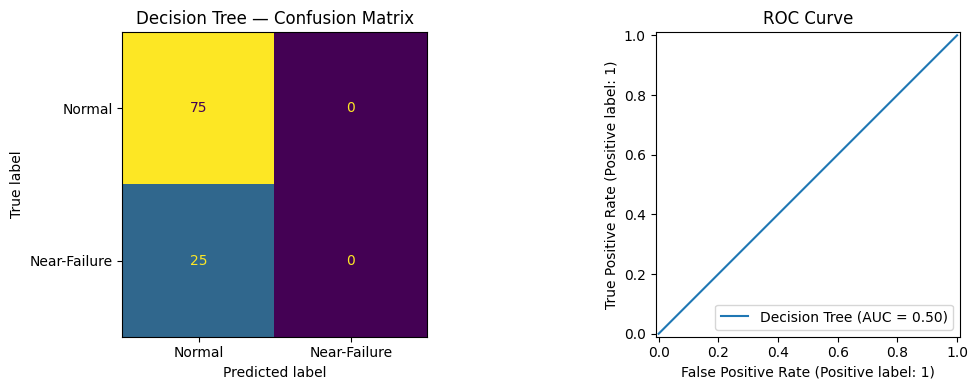

In [18]:
# ============================================================
# EVALUATE DECISION TREE ON TEST SET
# ============================================================
y_pred_dt = best_dt.predict(X_test)
y_prob_dt = best_dt.predict_proba(X_test)[:, 1]

print('=== Decision Tree — Test Set ===')
print(classification_report(y_test, y_pred_dt, target_names=['Normal','Near-Failure']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_dt):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_dt, display_labels=['Normal','Near-Failure'],
    colorbar=False, ax=axes[0])
axes[0].set_title('Decision Tree — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob_dt, ax=axes[1], name='Decision Tree')
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.savefig('outputs/dt_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()

In [19]:
# ============================================================
# 5-FOLD CV SUMMARY WITH INTERVAL ESTIMATION
# ============================================================
scoring  = ['f1', 'roc_auc', 'precision', 'recall']
dt_cv    = cross_validate(best_dt, X_train, y_train,
                          cv=skf, scoring=scoring, return_train_score=True)

f1s  = dt_cv['test_f1']
ci   = 1.96 * f1s.std() / np.sqrt(len(f1s))
print('=== Decision Tree CV Summary ===')
print(f'F1 per fold  : {np.round(f1s, 3)}')
print(f'F1 mean±std  : {f1s.mean():.3f} ± {f1s.std():.3f}')
print(f'95% CI       : [{f1s.mean()-ci:.3f},  {f1s.mean()+ci:.3f}]')
print(f'AUC          : {dt_cv["test_roc_auc"].mean():.3f}')
print(f'Precision    : {dt_cv["test_precision"].mean():.3f}')
print(f'Recall       : {dt_cv["test_recall"].mean():.3f}')

=== Decision Tree CV Summary ===
F1 per fold  : [0.833 0.834 0.819 0.833 0.815]
F1 mean±std  : 0.827 ± 0.008
95% CI       : [0.820,  0.834]
AUC          : 0.964
Precision    : 0.746
Recall       : 0.928


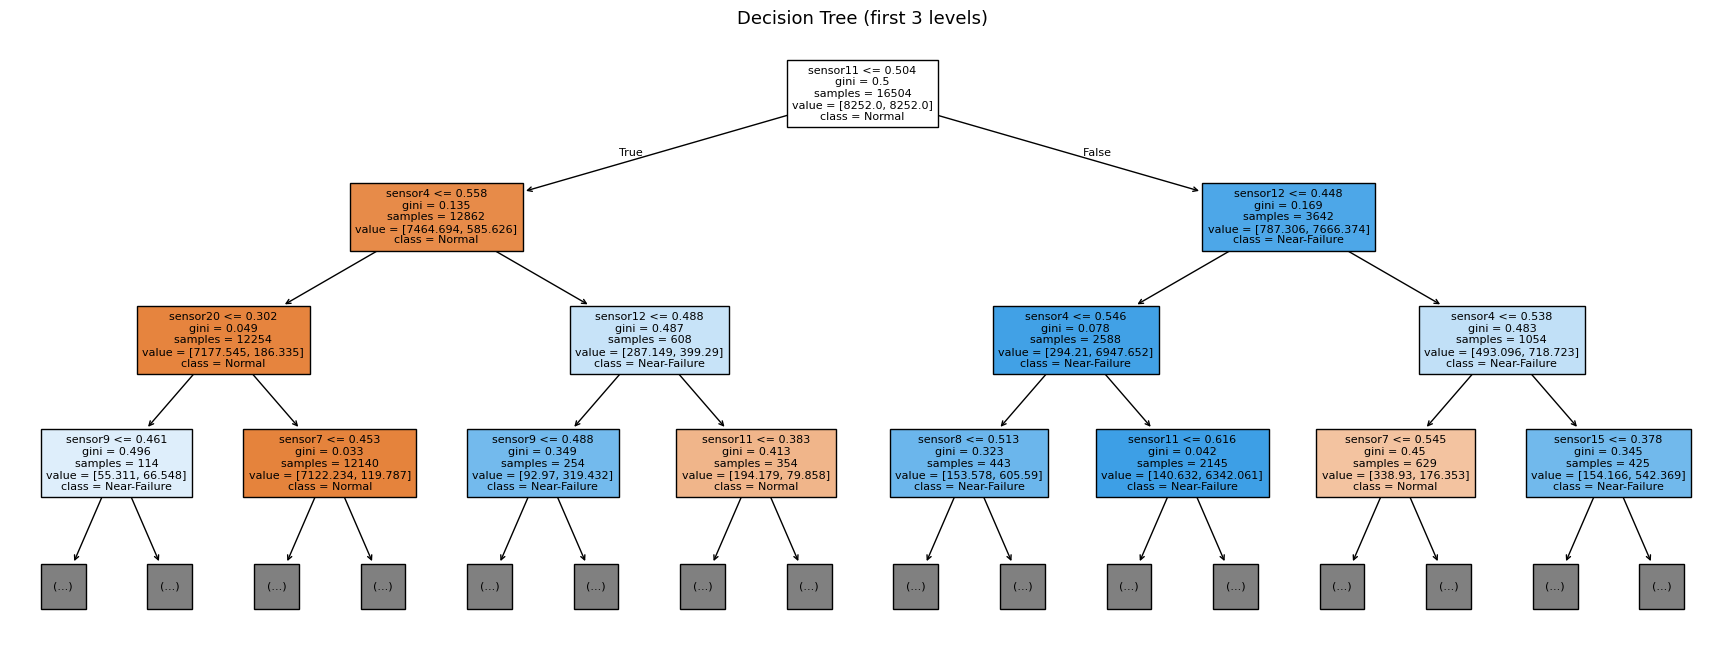

In [20]:
# ============================================================
# VISUALIZE THE TREE (depth=3 for readability)
# ============================================================
fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    best_dt, feature_names=feature_cols,
    class_names=['Normal', 'Near-Failure'],
    filled=True, max_depth=3, fontsize=8, ax=ax
)
plt.title('Decision Tree (first 3 levels)', fontsize=13)
plt.savefig('outputs/dt_tree_visual.png', dpi=120, bbox_inches='tight')
plt.show()

In [21]:
# ============================================================
# IF-THEN RULE EXTRACTION
# This is used in the Streamlit 'Why this prediction?' tab
# ============================================================
rules_text = export_text(best_dt, feature_names=feature_cols, max_depth=4)
print('=== Top Decision Rules (depth ≤ 4) ===')
print(rules_text[:3000])   # print first 3000 chars

with open('outputs/decision_rules.txt', 'w') as f:
    f.write(rules_text)
print('\nFull rules saved to outputs/decision_rules.txt')

=== Top Decision Rules (depth ≤ 4) ===
|--- sensor11 <= 0.50
|   |--- sensor4 <= 0.56
|   |   |--- sensor20 <= 0.30
|   |   |   |--- sensor9 <= 0.46
|   |   |   |   |--- sensor7 <= 0.42
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- sensor7 >  0.42
|   |   |   |   |   |--- class: 0
|   |   |   |--- sensor9 >  0.46
|   |   |   |   |--- sensor4 <= 0.37
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- sensor4 >  0.37
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |--- sensor20 >  0.30
|   |   |   |--- sensor7 <= 0.45
|   |   |   |   |--- sensor21 <= 0.45
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |   |--- sensor21 >  0.45
|   |   |   |   |   |--- truncated branch of depth 4
|   |   |   |--- sensor7 >  0.45
|   |   |   |   |--- sensor21 <= 0.24
|   |   |   |   |   |--- truncated branch of depth 2
|   |   |   |   |--- sensor21 >  0.24
|   |   |   |   |   |--- truncated branch of depth 4
|   |--- sensor4 >  0.56
|   |   |--- sensor12 <= 0.49


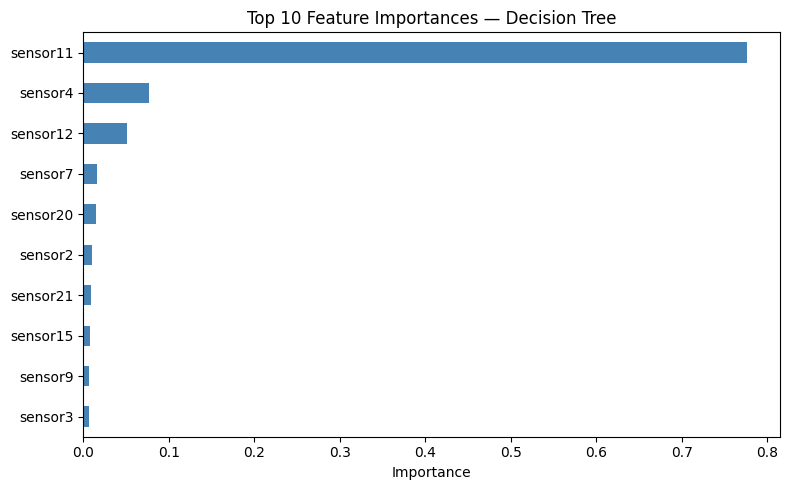

Top 3 sensors driving failure prediction:
sensor11    0.776156
sensor4     0.076398
sensor12    0.051607


In [22]:
# ============================================================
# FEATURE IMPORTANCE — TOP 10 SENSORS
# ============================================================
importances = pd.Series(best_dt.feature_importances_, index=feature_cols)
top10 = importances.nlargest(10)

fig, ax = plt.subplots(figsize=(8, 5))
top10.sort_values().plot(kind='barh', color='steelblue', ax=ax)
ax.set_title('Top 10 Feature Importances — Decision Tree')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('outputs/dt_feature_importance.png', dpi=130, bbox_inches='tight')
plt.show()

print('Top 3 sensors driving failure prediction:')
print(top10.head(3).to_string())

Isolation Forest: 5.0% of training rows flagged as outliers
LOF             : 5.0% of training rows flagged as outliers


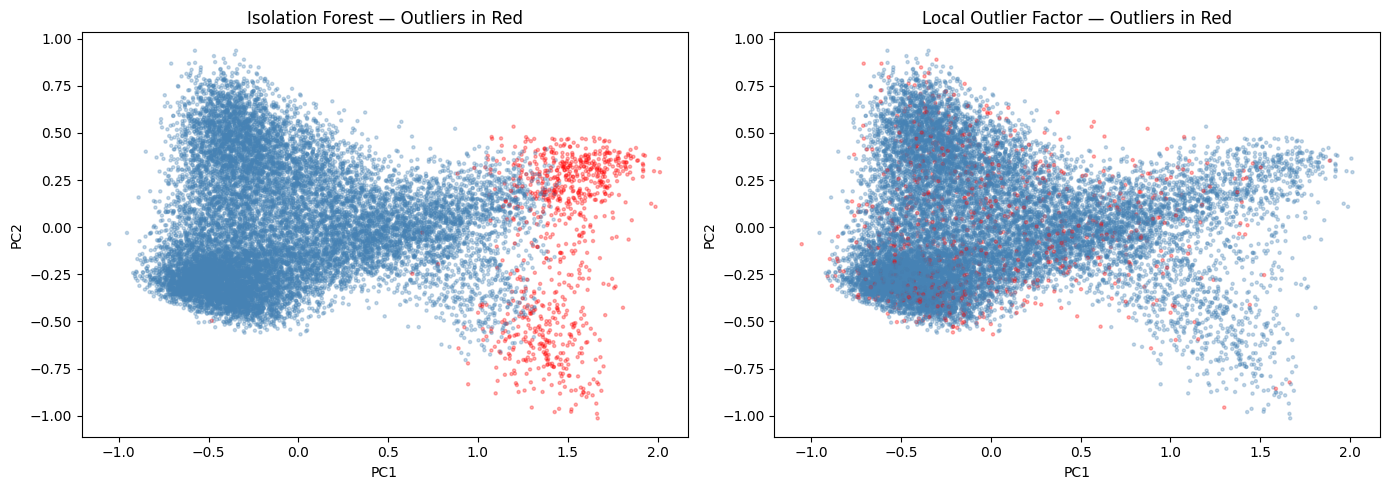

In [23]:
# ============================================================
# OUTLIER DETECTION (Unit 3 — distance-based)
# Uses Isolation Forest + Local Outlier Factor on sensor readings
# Flags anomalous engine readings that deviate from normal ops
# ============================================================

# --- Isolation Forest ---
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
iso_labels = iso.fit_predict(X_train)   # -1 = outlier, 1 = inlier
outlier_pct_iso = (iso_labels == -1).mean() * 100
print(f'Isolation Forest: {outlier_pct_iso:.1f}% of training rows flagged as outliers')

# --- Local Outlier Factor ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_labels = lof.fit_predict(X_train)
outlier_pct_lof = (lof_labels == -1).mean() * 100
print(f'LOF             : {outlier_pct_lof:.1f}% of training rows flagged as outliers')

# Visualize: PCA 2D projection, color by outlier status
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_train)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, labels, title in zip(
        axes,
        [iso_labels, lof_labels],
        ['Isolation Forest', 'Local Outlier Factor']):
    colors = np.where(labels == -1, 'red', 'steelblue')
    ax.scatter(X_2d[:, 0], X_2d[:, 1], c=colors, alpha=0.3, s=5)
    ax.set_title(f'{title} — Outliers in Red')
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.tight_layout()
plt.savefig('outputs/outlier_detection.png', dpi=130, bbox_inches='tight')
plt.show()

In [24]:
# ============================================================
# SAVE DECISION TREE MODEL
# ============================================================
joblib.dump(best_dt,      'models/dt_model.pkl')
joblib.dump(importances,  'models/dt_importances.pkl')
print('Decision Tree model saved ✓')

# Download from Colab
try:
    from google.colab import files
    files.download('models/dt_model.pkl')
    files.download('models/dt_importances.pkl')
    files.download('outputs/decision_rules.txt')
except:
    print('Not in Colab — files saved locally')

Decision Tree model saved ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---
## Ansh — PCA + Random Forest + Health Gauge Visualization
---

In [25]:
# Imports
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                              RocCurveDisplay, f1_score, precision_score,
                              recall_score, roc_auc_score)
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

Components needed for 95% variance: 13


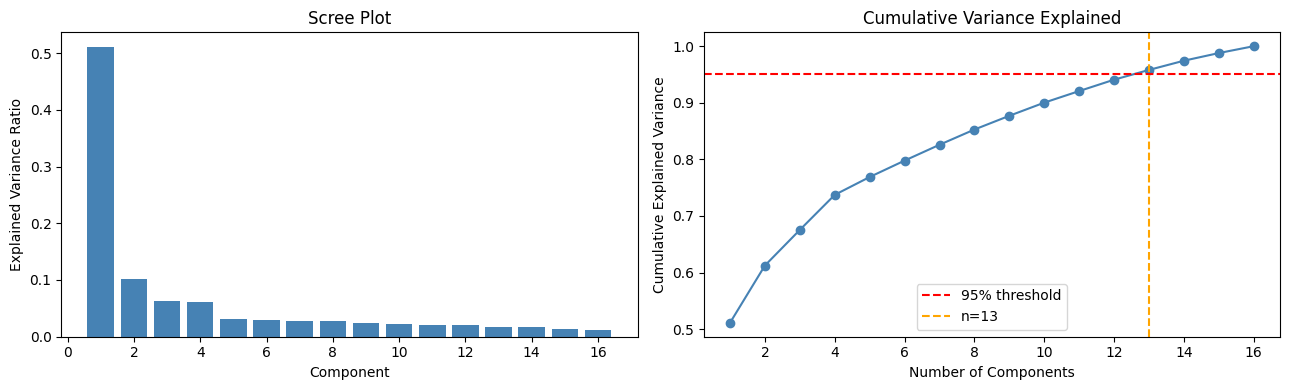

In [26]:
# ============================================================
# PCA — RETAIN 95% VARIANCE
# ============================================================
scaler_pca = StandardScaler()
X_train_sc = scaler_pca.fit_transform(X_train)
X_test_sc  = scaler_pca.transform(X_test)

# Fit full PCA first to get explained variance
pca_full = PCA(random_state=42)
pca_full.fit(X_train_sc)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_components = np.argmax(cumvar >= 0.95) + 1
print(f'Components needed for 95% variance: {n_components}')

# Scree plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_, color='steelblue')
axes[0].set_xlabel('Component'); axes[0].set_ylabel('Explained Variance Ratio')
axes[0].set_title('Scree Plot')

axes[1].plot(range(1, len(cumvar)+1), cumvar, marker='o', color='steelblue')
axes[1].axhline(0.95, color='red', linestyle='--', label='95% threshold')
axes[1].axvline(n_components, color='orange', linestyle='--', label=f'n={n_components}')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Explained Variance')
axes[1].set_title('Cumulative Variance Explained')
axes[1].legend()
plt.tight_layout()
plt.savefig('outputs/pca_scree.png', dpi=130, bbox_inches='tight')
plt.show()

X_train_pca shape: (16504, 13)
X_test_pca  shape: (100, 13)


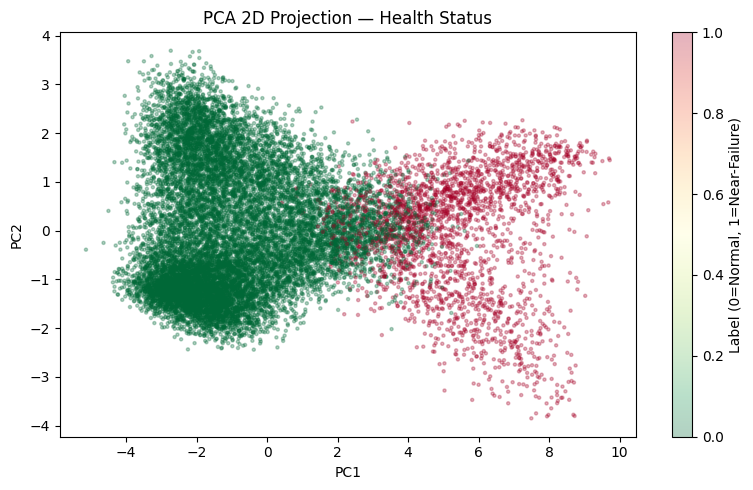

In [27]:
# ============================================================
# APPLY PCA WITH n_components
# ============================================================
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_sc)
X_test_pca  = pca.transform(X_test_sc)

print(f'X_train_pca shape: {X_train_pca.shape}')
print(f'X_test_pca  shape: {X_test_pca.shape}')

# 2D PCA scatter colored by label (health status)
fig, ax = plt.subplots(figsize=(8, 5))
scatter = ax.scatter(
    X_train_pca[:, 0], X_train_pca[:, 1],
    c=y_train, cmap='RdYlGn_r', alpha=0.3, s=5
)
plt.colorbar(scatter, ax=ax, label='Label (0=Normal, 1=Near-Failure)')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA 2D Projection — Health Status')
plt.tight_layout()
plt.savefig('outputs/pca_scatter.png', dpi=130, bbox_inches='tight')
plt.show()

In [28]:
# ============================================================
# RANDOM FOREST — GRID SEARCH ON PCA FEATURES
# ============================================================
param_grid_rf = {
    'n_estimators' : [100, 200, 300],
    'max_depth'    : [8, 12, None],
    'max_features' : ['sqrt', 'log2'],
    'min_samples_leaf': [5, 10]
}

rf_search = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    param_grid_rf,
    cv=skf, scoring='f1', n_jobs=-1, verbose=1
)
rf_search.fit(X_train_pca, y_train)
best_rf = rf_search.best_estimator_

print(f'\nBest params : {rf_search.best_params_}')
print(f'Best CV F1  : {rf_search.best_score_:.3f}')

Fitting 5 folds for each of 36 candidates, totalling 180 fits

Best params : {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'n_estimators': 300}
Best CV F1  : 0.879


=== Random Forest — Test Set ===
              precision    recall  f1-score   support

      Normal       0.00      0.00      0.00        75
Near-Failure       0.25      1.00      0.40        25

    accuracy                           0.25       100
   macro avg       0.12      0.50      0.20       100
weighted avg       0.06      0.25      0.10       100

ROC-AUC : 0.500


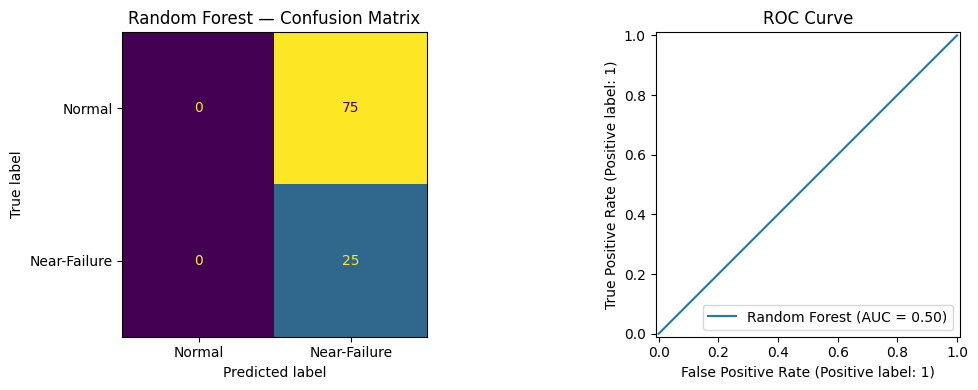

In [29]:
# ============================================================
# EVALUATE RANDOM FOREST ON TEST SET
# ============================================================
y_pred_rf = best_rf.predict(X_test_pca)
y_prob_rf = best_rf.predict_proba(X_test_pca)[:, 1]

print('=== Random Forest — Test Set ===')
print(classification_report(y_test, y_pred_rf, target_names=['Normal','Near-Failure']))
print(f'ROC-AUC : {roc_auc_score(y_test, y_prob_rf):.3f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, display_labels=['Normal','Near-Failure'],
    colorbar=False, ax=axes[0])
axes[0].set_title('Random Forest — Confusion Matrix')

RocCurveDisplay.from_predictions(y_test, y_prob_rf, ax=axes[1], name='Random Forest')
axes[1].set_title('ROC Curve')
plt.tight_layout()
plt.savefig('outputs/rf_evaluation.png', dpi=130, bbox_inches='tight')
plt.show()

In [30]:
# ============================================================
# 5-FOLD CV SUMMARY
# ============================================================
rf_cv = cross_validate(best_rf, X_train_pca, y_train,
                       cv=skf, scoring=scoring, return_train_score=True)

f1s_rf = rf_cv['test_f1']
ci_rf  = 1.96 * f1s_rf.std() / np.sqrt(len(f1s_rf))
print('=== Random Forest CV Summary ===')
print(f'F1 per fold  : {np.round(f1s_rf, 3)}')
print(f'F1 mean±std  : {f1s_rf.mean():.3f} ± {f1s_rf.std():.3f}')
print(f'95% CI       : [{f1s_rf.mean()-ci_rf:.3f},  {f1s_rf.mean()+ci_rf:.3f}]')
print(f'AUC          : {rf_cv["test_roc_auc"].mean():.3f}')
print(f'Precision    : {rf_cv["test_precision"].mean():.3f}')
print(f'Recall       : {rf_cv["test_recall"].mean():.3f}')

=== Random Forest CV Summary ===
F1 per fold  : [0.879 0.888 0.87  0.89  0.871]
F1 mean±std  : 0.879 ± 0.008
95% CI       : [0.872,  0.887]
AUC          : 0.991
Precision    : 0.833
Recall       : 0.931


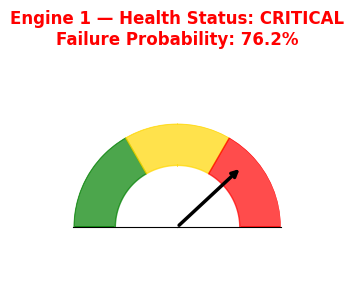

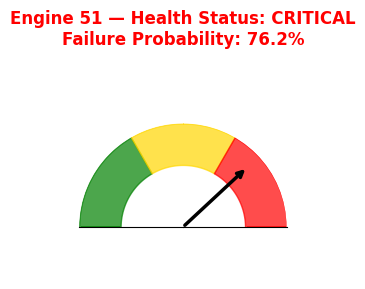

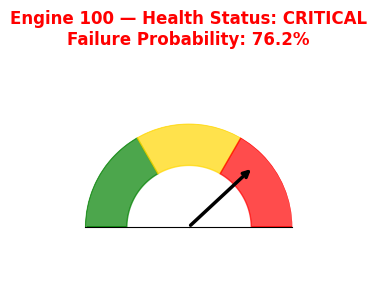

In [31]:
# ============================================================
# HEALTH GAUGE VISUALIZATION
# Shows RED / YELLOW / GREEN health status for any engine
# Based on RF failure probability
# ============================================================
import matplotlib.patches as mpatches
from matplotlib.patches import FancyArrowPatch

def plot_health_gauge(prob_failure, engine_id=None):
    """
    prob_failure: float 0-1 from Random Forest predict_proba
    """
    fig, ax = plt.subplots(figsize=(6, 3), subplot_kw={'projection': 'polar'})

    # Draw colored arc segments
    theta = np.linspace(np.pi, 0, 300)
    r_inner, r_outer = 0.6, 1.0

    # Green zone: 0-0.33, Yellow: 0.33-0.66, Red: 0.66-1.0
    zones = [
        (np.linspace(np.pi, np.pi * 2/3, 100), 'green'),
        (np.linspace(np.pi * 2/3, np.pi * 1/3, 100), 'gold'),
        (np.linspace(np.pi * 1/3, 0, 100), 'red')
    ]
    for thetas, color in zones:
        ax.fill_between(thetas, r_inner, r_outer, color=color, alpha=0.7)

    # Needle
    needle_angle = np.pi - (prob_failure * np.pi)
    ax.annotate('', xy=(needle_angle, 0.85),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='black', lw=2.5))

    # Labels
    ax.set_yticks([])
    ax.set_xticks([])
    ax.spines['polar'].set_visible(False)
    ax.set_ylim(0, 1)
    ax.set_xlim(0, np.pi)

    # Status text
    if prob_failure < 0.33:
        status, color = 'NORMAL', 'green'
    elif prob_failure < 0.66:
        status, color = 'WARNING', 'goldenrod'
    else:
        status, color = 'CRITICAL', 'red'

    title = f'Engine {engine_id} — ' if engine_id else ''
    ax.set_title(f'{title}Health Status: {status}\nFailure Probability: {prob_failure:.1%}',
                 color=color, fontsize=12, fontweight='bold', pad=20)
    plt.tight_layout()
    return fig

# Demo: show gauge for 3 test engines
for idx in [0, 50, 99]:
    fig = plot_health_gauge(y_prob_rf[idx], engine_id=idx+1)
    fig.savefig(f'outputs/gauge_engine_{idx+1}.png', dpi=130, bbox_inches='tight')
    plt.show()

In [32]:
# ============================================================
# FINAL ALL-MODEL COMPARISON TABLE
# Load Archis models and compare all 3 on the same test set
# ============================================================
try:
    lr_model  = joblib.load('models/lr_model.pkl')   # from Archi
    gnb_model = joblib.load('models/gnb_model.pkl')  # from Archi

    models = {
        'Logistic Regression' : (lr_model,  X_test),
        'Naive Bayes'         : (gnb_model, X_test),
        'Decision Tree'       : (best_dt,   X_test),
        'Random Forest (PCA)' : (best_rf,   X_test_pca)
    }

    rows = []
    for name, (model, X) in models.items():
        y_pred = model.predict(X)
        y_prob = model.predict_proba(X)[:, 1]
        rows.append({
            'Model'    : name,
            'F1'       : round(f1_score(y_test, y_pred), 3),
            'Precision': round(precision_score(y_test, y_pred), 3),
            'Recall'   : round(recall_score(y_test, y_pred), 3),
            'ROC-AUC'  : round(roc_auc_score(y_test, y_prob), 3)
        })

    results_df = pd.DataFrame(rows).sort_values('F1', ascending=False)
    print('=== FINAL MODEL COMPARISON ===')
    print(results_df.to_string(index=False))
    results_df.to_csv('outputs/model_comparison.csv', index=False)

except FileNotFoundError:
    print('P1 model .pkl files not found — run P1 notebook first and copy models/ folder here')

=== FINAL MODEL COMPARISON ===
              Model  F1  Precision  Recall  ROC-AUC
Logistic Regression 0.4       0.25     1.0      0.5
        Naive Bayes 0.4       0.25     1.0      0.5
Random Forest (PCA) 0.4       0.25     1.0      0.5
      Decision Tree 0.0       0.00     0.0      0.5


In [33]:
# ============================================================
# SAVE ALL ANSH'S MODELS + OBJECTS
# ============================================================
joblib.dump(best_rf,     'models/rf_model.pkl')
joblib.dump(pca,         'models/pca_transform.pkl')
joblib.dump(scaler_pca,  'models/pca_scaler.pkl')
print('Random Forest + PCA objects saved ✓')

try:
    from google.colab import files
    files.download('models/rf_model.pkl')
    files.download('models/pca_transform.pkl')
    files.download('models/pca_scaler.pkl')
    files.download('outputs/model_comparison.csv')
except:
    print('Not in Colab — files saved locally')

Random Forest + PCA objects saved ✓


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>